<a href="https://colab.research.google.com/github/LisethTiria/Biosenales-2025-1/blob/main/Practica6/FiltrosDigitales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="logo_udea.png" alt="Logo UdeA" style="height: 80px;">
  <div>
    <h1 style="margin: 0; font-size: 2em;">Práctica 6: Diseño de Filtros Digitales</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>

## Creación de la señal

Se creará una secuencia sinusoidal $𝑥_e(𝑛)$, con $0≤𝑛≤1000, 𝐹_0=0,01$ Hz y $𝐹_𝑠=25$ Hz generada por un proceso electrofisiológico.

El viaje de la señal hipotética $𝑥_𝑒(𝑛)$ a través de los diversos tejidos genera una atenuación en la amplitud y un retraso temporal. La señal registrada finalmente es de la forma: $𝑦_𝑒(𝑛)=\alpha 𝑥_𝑒(𝑛−𝐷)+𝑤(𝑛)$

Donde $\alpha\$ representa la amplitud, D es un retraso debido a la conducción a través de los diversos tejidos y 𝑤(𝑛) representa el ruido generado por la electrónica de los sistemas de adquisición.

la señal 𝑤(𝑛) fue implementada como una secuencia de ruido Gaussiano con media cero y varianza $𝜎^2=0,01$, establezca $\alpha=0,8$ y un retraso 𝐷=15 muestras. Grafique ambas señales.



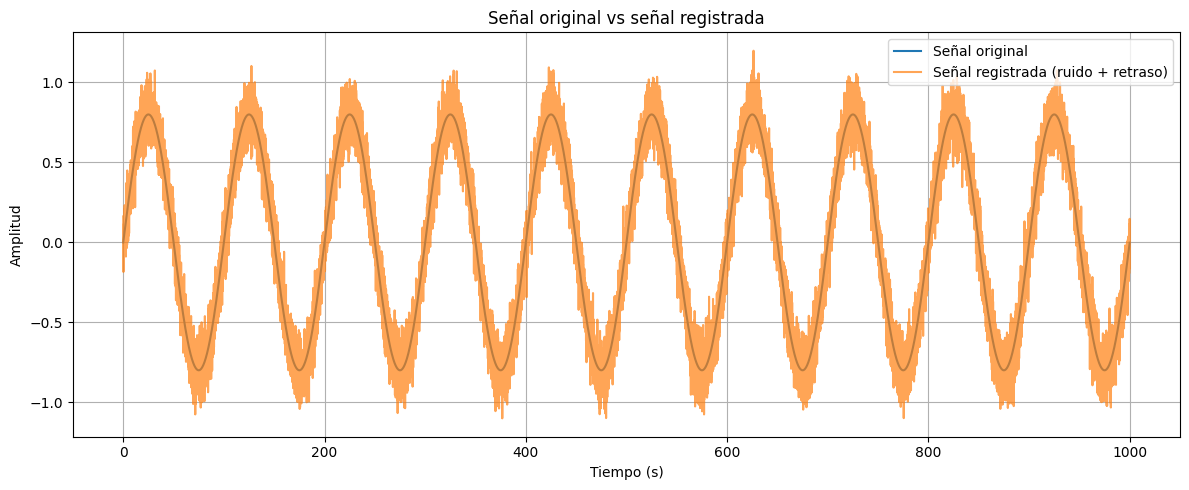

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal
fs = 25  # Frecuencia de muestreo (Hz)
f = 0.01    # Frecuencia de la señal (Hz)
alpha = 0.8  # Amplitud original
D = 15    # Número de muestras de retraso
t = np.arange(0, 1000, 1/fs)

# Señal original
x = alpha * np.sin(2 * np.pi * f * t)

# Ruido gaussiano
ruido = np.random.normal(0, 0.1, len(t))  # media=0, varianza=0.01

# Señal retrasada
x_d = np.zeros_like(x)
x_d[D:] = x[:-D]

# Señal con ruido y retraso (señal registrada)
x_r = x_d + ruido

# Graficar señales
plt.figure(figsize=(12, 5))
plt.plot(t, x, label='Señal original')
plt.plot(t, x_r, label='Señal registrada (ruido + retraso)', alpha=0.7)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal original vs señal registrada")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
